<!-- # CMPUT 200 Fall 2024  Ethics of Data Science and AI
 -->
# Assignment 1: Fairness Analysis of a Dataset

***
- **FIRST name**: Moffat
- **LAST name**: Muriithi
- **Student ID**:
- **Dataset**: employee_attrition.csv

In this assignment, you will explore the different fairness metrics learnt in class using a dataset of your choice. Before beginning, you will have to inspect the data and determine the variable of interest (i.e. the outcome) and at least two sensitive features. After each step of your analysis, you will write an in-depth analysis of your results.

This notebook has four stages in which we will:
1. Import the data, implement a few pre-processing steps, and inspect the data
2. Run a short exploratory analysis of the primary variable of interest of your dataset
3. Reproduce the logistic regression model  and interpret the estimates
4. Compute the predictive accuracy of the risk score labels

### Instructions
- **Group Work**: The assignments can be completed in groups of two or alone. If you choose to complete an assignment as a group of two, both members of the group must submit a notebook file on Canvas by the deadline. Everyone must include the names of all group members in the header of the submitted assignment.
- **Software**: You are expected to use the syzygy platform:  <https://ualberta.syzygy.ca>.  You will upload the notebooks and datasets we provide to that platform and implement your code and run the notebook on that server.  Here are instructions on using syzygy:  [Using syzygy](https://docs.google.com/document/d/e/2PACX-1vSzNHJfWRYRMD929DXVKl_RSsY6aNnvmEzE64_s3kVRHwa6z79oCrCqdyEv4Jf-DTrUSMqNVav29zKN/pub)
- **Filling out the Notebook**: You must use this notebook to complete your lab. You will execute the questions in the notebook. The questions might ask for a short answer in text form or for you to write and execute a piece of code. Make sure you enter your answer in either case **only** in the cell provided.
- **Important**:  Do not use a different cell, do not delete cells, and do not create a new cell. Creating new cells for your code is not compatible with the auto-grading system we are using and thus your assignment will not get graded properly and you will lose marks for that question. As a reminder you must remove the raise NotImplementedError() statements from each question when answering.
- **Rules for Datasets**: Any datasets used in the lab cannot be imported from cloud storage, e.g google drive, and must be read from a file stored in your folder on the syzygy platform.  Use only the datasets provided for you.
- **Submission Formatting**: When you are done, you will submit your work from the notebook. Make sure to save your notebook before running it, download it, and then submit on Canvas the notebook file with your work completed (see [Using syzygy](https://docs.google.com/document/d/e/2PACX-1vSzNHJfWRYRMD929DXVKl_RSsY6aNnvmEzE64_s3kVRHwa6z79oCrCqdyEv4Jf-DTrUSMqNVav29zKN/pub) for instructions). Name your file with your Student ID number, followed by an underscore and A plus the assignment number followed by an underscore and the dataset name (without .csv) (ex: 1234567_A1_employee.ipynb). Failure to do so will result in a zero! Finally your name must be written at the top of the lab or assignment document.

In [1]:
# Don't change this cell; just run it.
import numpy as np
from numpy.random import default_rng
import pandas as pd
from scipy.optimize import minimize
import statsmodels.api as sm

# These lines do some fancy plotting magic.
import matplotlib
# This is a magic function that renders the figure in the notebook, instead of displaying a dump of the figure object.
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import seaborn as sns
import warnings
warnings.simplefilter('ignore', FutureWarning)

In [2]:
# Don't change this cell; just run it.
rng_seed = 42
rng = default_rng(rng_seed)
rngstate = np.random.RandomState(rng_seed)

## Data
**Question 1.** We will first load the data, carry out some cleaning and pre-processing, and inspect the data to understand what exploratory steps we will take. Name the DataFrame `df_init` and drop the missing values.

In [3]:
# YOUR CODE HERE
employee = pd.read_csv("employee_attrition.csv")
df_init = pd.DataFrame(employee)
df_init = df_init.replace('?', np.nan)
df_init = df_init.dropna()

print("Shape: ", df_init.shape)
df_init.head(5)

Shape:  (14900, 24)


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,52685,36,Male,13,Healthcare,8029,Excellent,High,Average,1,...,1,Mid,Large,22,No,No,No,Poor,Medium,Stayed
1,30585,35,Male,7,Education,4563,Good,High,Average,1,...,4,Entry,Medium,27,No,No,No,Good,High,Left
2,54656,50,Male,7,Education,5583,Fair,High,Average,3,...,2,Senior,Medium,76,No,No,Yes,Good,Low,Stayed
3,33442,58,Male,44,Media,5525,Fair,Very High,High,0,...,4,Entry,Medium,96,No,No,No,Poor,Low,Left
4,15667,39,Male,24,Education,4604,Good,High,Average,0,...,6,Mid,Large,45,Yes,No,No,Good,High,Stayed


In [4]:
# CELL USED FOR AUTOGRADER: do not delete!

YOUR ANSWER HERE

### Data pre-processing
**Question 2.**
Please read the whole assignment once over before starting. Think about the questions and how you will work on them as you go. This will help immensely with the assignment and reduce any difficulties you encounter overall.

You will now follow your dataset's methodology in pre-processing the data.  Note that your data may not be already filtered, so there may be rows that are not needed or missing values (NaN).  In your pre-processing, first retain only relevant columns for ease of analysis and inspection.  Relevant columns are those that you will need for analysis in this assignment - please read the whole assignment once over to determine which columns to retain. You will need to retain all columns with sensitive features, the output columns, and other columns that contain features needed for the analysis. Once you've retained the columns you want, remove the rows that are missing data (if needed).  

For this assignment we have specified two sets of prospective sensitive features for you to choose your senstive features from. Please read through the whole assignment first and select what features you are going to be using before you start coding anything.

In the following table, based on your chosen dataset, we have made 2 groupings of sensitive features. Chose your first and second sensitive features from these respective groupings. For each suggested feature of your dataset, you must justify why it is or is not a senstive feature. In the cell after list the columns you are going to retain for the dataset and complete any other pre processing that needs to be done. Further information for these datasets can be found at #debug

| Dataset | Sensitive Feature 1| Sensitive Feature 2 |                   
|----------|----------|-----------|
| Employee Attrition | Age, Job role, Monthly Income, Preformance Rating  | Gender, Job Satisfaction, Number of Promotions, Marital Status |
| Law | Race, LSAT, Bar, Parttime  | Cluster, Dropout, Sex, Fulltime |
| German Credit | Account balance, Duration of Credit, Payment Status, Purpose  | Credit Amount, Length of Current Employment, Sex and Marital Status, Occupation |
| Adult | Education, Marital Status, Capital Loss, Income  | Occupation, Relationship, Race, Sex |

From the First Group(Sensitive Feature 1):
- Age: sensitive feature. This is an attribute that can be tied to an individual and can lead to bias.It is an indiret PII (Personally Identifiable Information).
- Job role: non-sensitive feature. It is a descriptive attribute that cannot be directly tied to one individual directly.
- Monthly income: non-sensitive feature. An attribute tied to one's role.
- Performance Rating: non-sensitive feature. A work measurement scale that cannot be directly tied to a particular individual.

From the Second Group (Sensitive Feature 2):
- Gender: sensitive feature. An attribute that can led to bias of a group or a particular individual. It is an indirect PII.
- Job Satisfaction: non-sensitive feature. A self reported attribute that cannot be tied to one individual directly.
- Number of Promotions: non-sensitive feature. An attribute that shows outcome in career progression. D
- Marital Status: sensitive feature. Can be directed to a particular person and can cause discrimination It is an indirect PII.

Next, determine if you have to do any more filtering (e.g. maybe you only want to consider individuals between 20 and 30 years old). Also decide if there are any any values that you want to remove (e.g. maybe you want to remove people classified as '0' for a medical condition). You may also have certain columns that are excessivley sparse due to problems with data collection, be sure to go over your dataset to check for variables that lack sufficient data to be useful.

In [5]:
cols_retain = []

# YOUR CODE HERE
# Relevant columns we want to keep for the analysis.
# Removed 'Employee ID'
cols_retain = ['Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 
    'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 
    'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 
    'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 
    'Company Tenure', 'Remote Work', 'Leadership Opportunities', 
    'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition']

df_init = df_init[cols_retain]

**Question 2.1.** We will be working with your dataset's variable of interest, which is the output, or label.  You would have determined what this should be in the previous questions.  Let's first be certain the values are numeric.  You would use `pd.to_numeric`.  Note that there might be NaN values, and if so, you should drop those rows.

In [6]:
# YOUR CODE HERE
# Left becomes 1, and Stayed becomes 0.
df_init['Attrition'] = df_init['Attrition'].map({'Left': 1, 'Stayed': 0})

df_init['Attrition'] = pd.to_numeric(df_init['Attrition'], errors='coerce')
df_init = df_init.dropna(subset=['Attrition'])

### Data exploration
Let us now explore the statistics of the data.  Your data contains a variable of interest, which is the output.  Our goal is to compare the analysis of these outputs with the outputs of a logistic regression model we will build ourselves.

We will plot the distribution of the variable of interest according to the first sensitive feature (that you defined in question 1) to see how it differs across different subgroups.

**Question 3.** Let's first create dataframes that are specific to the different subgroups of your sensitive variable.  First choose In the cell below, create the new dataframes `df_1` and `df_2` so that `df_1` holds all the rows that correspond to the first subgroup and `df_2` holds all the rows that correspond to the second subgroup. If there are more than 2 subgroups, find a way to categorize them into two categories. You may change the names so that it's more specific to your dataset.

In [7]:
# YOUR CODE HERE
# Our first sensitive feature is 'Age'. Two Subgroups:
# Subgroup 1: Employees under the age of 35
df_1 = df_init[df_init['Age'] < 35]

# Subgroup 2: Employees aged 35 and older
df_2 = df_init[df_init['Age'] >= 35]

**Question 3.1.** Now we will plot histograms for these new dataframes.  The histogram will have the variable of interest (output variable) on the x axis, n bins corresponding to the n values possible. The y axis will be the _proportion_ of individuals of each subgroup that have that variable of interest.  So the y values for each subgroup will be the number of individuals having a given value divided by the total number of individuals of that subgroup.

You can choose how you want to represent the histograms:  separate sub plots side by side, or all on one plot with different colours each, etc.  The axis limits should be same on both plots (same scale) and the plots should have appropriate titles, axis labels, and if needed a legend.

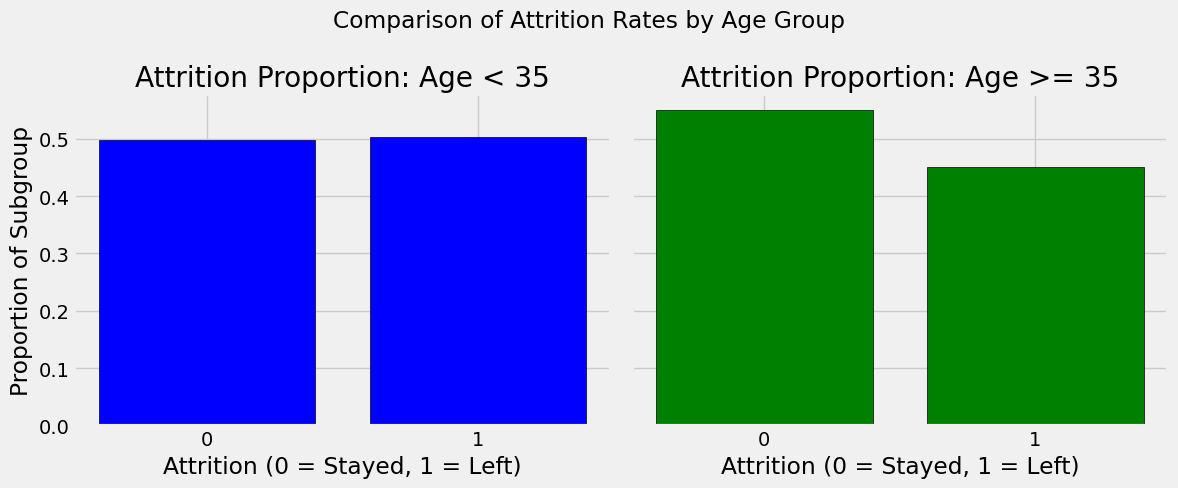

In [8]:
# YOUR CODE HERE
prop_1 = df_1['Attrition'].value_counts(normalize=True).sort_index()
prop_2 = df_2['Attrition'].value_counts(normalize=True).sort_index()

# Set up a side-by-side plot with a shared Y-axis so the proportions are visually comparable
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot for Subgroup 1 (Under 35)
ax[0].bar(prop_1.index.astype(str), prop_1.values, color='blue', edgecolor='black')
ax[0].set_title('Attrition Proportion: Age < 35')
ax[0].set_xlabel('Attrition (0 = Stayed, 1 = Left)')
ax[0].set_ylabel('Proportion of Subgroup')

# Plot for Subgroup 2 (35 and Older)
ax[1].bar(prop_2.index.astype(str), prop_2.values, color='green', edgecolor='black')
ax[1].set_title('Attrition Proportion: Age >= 35')
ax[1].set_xlabel('Attrition (0 = Stayed, 1 = Left)')

# Add an overall title and display the plot
plt.suptitle('Comparison of Attrition Rates by Age Group')
plt.tight_layout()
plt.show()


**Question 3.2.** Describe the plots, especially any differences you see between them.  What does this tell you about the distribution of the variable of interest with respect to the sensitive feature?

The histograms display the normalized proportion of employee attrition, separated by our first sensitive feature, Age. There is a difference in the distribution of our variable of interest between the two subgroups. The proportion of attrition (where the label equals 1.0) is noticeably higher in the Age < 35 subgroup compared to the Age >= 35 subgroup. This tells us that the distribution of attrition is not equal with respect to age; younger employees are leaving the company at almost twice the rate of older employees.

We will now consider the second sensitive feature.  Follow the same steps as above.

**Question 4.** Create dataframes that are specific to the subgroups for your second sensitive feature.  In the cell below, create the new dataframes `df_a` and `df_b` so that `df_a` holds all the rows that correspond to the first subgroup and `df_b` holds all the rows that correspond to the second subgroup. If there are more than 2 subgroups, find a way to categorize them into two categories. You may change the names so that it's more specific to your dataset.

In [9]:
# YOUR CODE HERE
# Second sensitive feature: Gender 

# Subgroup a: Male employees
df_a = df_init[df_init['Gender'] == 'Male']

# Subgroup b: Female employees
df_b = df_init[df_init['Gender'] == 'Female']

**Question 4.1.** Now we will plot histograms for these new dataframes.  The histogram will have the variable of interest (output variable) on the x axis, n bins corresponding to the n values possible. The y axis will be the _proportion_ of individuals of each subgroup that have that variable of interest.  So the y values for each subgroup will be the number of individuals having a given value divided by the total number of individuals of that subgroup.

You can choose how you want to represent the histograms:  separate sub plots side by side, or all on one plot with different colours each, etc.  The axis limits should be same on both plots (same scale) and the plots should have appropriate titles, axis labels, and if needed a legend.

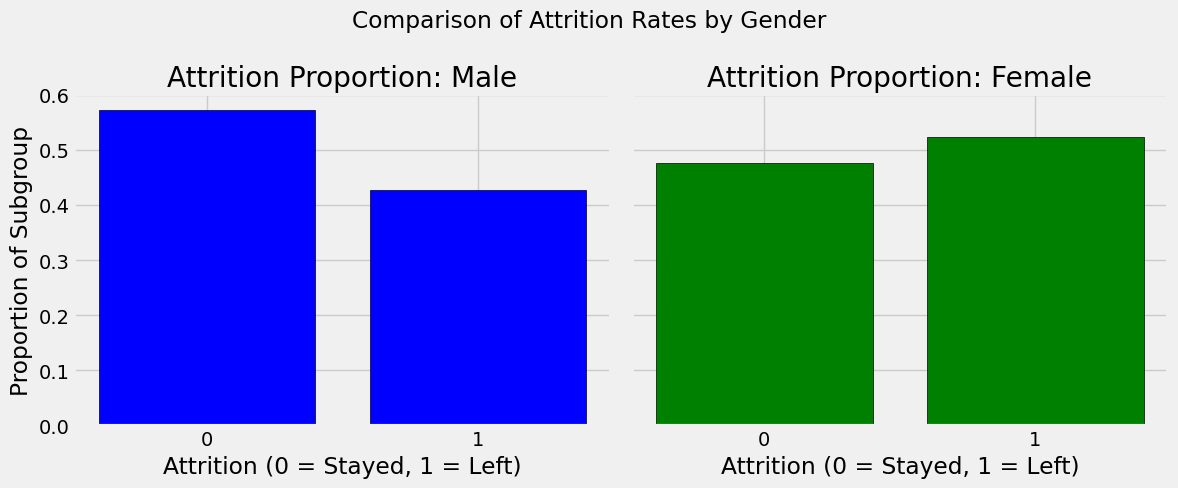

In [10]:
# YOUR CODE HERE
# Calculate the proportion of Attrition subgroup
prop_a = df_a['Attrition'].value_counts(normalize=True).sort_index()
prop_b = df_b['Attrition'].value_counts(normalize=True).sort_index()

# Set up a side-by-side plot with a shared Y-axis
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot for Subgroup A (Male)
ax[0].bar(prop_a.index.astype(str), prop_a.values, color='blue', edgecolor='black')
ax[0].set_title('Attrition Proportion: Male')
ax[0].set_xlabel('Attrition (0 = Stayed, 1 = Left)')
ax[0].set_ylabel('Proportion of Subgroup')

# Plot for Subgroup B (Female)
ax[1].bar(prop_b.index.astype(str), prop_b.values, color='green', edgecolor='black')
ax[1].set_title('Attrition Proportion: Female')
ax[1].set_xlabel('Attrition (0 = Stayed, 1 = Left)')

# Add overall title and display
plt.suptitle('Comparison of Attrition Rates by Gender')
plt.tight_layout()
plt.show()

**Question 4.2.** Describe the two plots, especially any differences you see between them.  What does this tell you about the distribution of the variable of interest with respect to the second sensitive feature?

The histograms display the normalized proportion of employee attrition, separated by our second sensitive feature, Gender: Male vs Female. The proportion of employees who left the company (Attrition = 1) is relatively similar between the two subgroups. The male subgroup shows an attrition rate slightly lower than the female subgroup. The distribution is fairly balanced with respect to gender as compared to the differences from the age variable.

## Fairness / Bias in the Dataset

Now we will develop our own logistic regression model to predict the output given the data and see how it does with respect to fairness metrics.

#### Pre-processing
We first have some preprocessing to do.

Logistic regression is used here as a classification algorithm, so it will give binary outputs. We will use `sklearn`'s logistic regression model which takes numerical input.  Your dataset's outcomes may be categorical variables. If this is the case, we will have to convert the categorical features to numerical features.  We will use [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) for this.

**Question 5.** Let's first set up a dataframe for the label, or target values. In the cell below extract that column into a separate dataframe, our target dataframe. Assign your answer to the variable `Y`.

In [11]:
# YOUR CODE HERE
# Target column
Y = df_init['Attrition']
# Display the first few rows to confirm
print("Target Variable (Y) Shape:", Y.shape)
Y.head()

Target Variable (Y) Shape: (14900,)


0    0
1    1
2    0
3    1
4    0
Name: Attrition, dtype: int64

In [12]:
# CELL USED FOR AUTOGRADER: do not delete!

**Question 5.1.** Now Let's set up the remaining data. Create another dataframe named `X` that contains every column *except* the target column.

In [13]:
# YOUR CODE HERE
# Features
# Removing Attrition to remain with the other columns
X = df_init.drop(columns=['Attrition'])
# Display the shape to confirm it has one less column than df_init
print("Features DataFrame (X) Shape:", X.shape)
X.head()

Features DataFrame (X) Shape: (14900, 22)


,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,...,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition
0,36,Male,13,Healthcare,8029,Excellent,High,Average,1,Yes,...,Married,1,Mid,Large,22,No,No,No,Poor,Medium
1,35,Male,7,Education,4563,Good,High,Average,1,Yes,...,Single,4,Entry,Medium,27,No,No,No,Good,High
2,50,Male,7,Education,5583,Fair,High,Average,3,Yes,...,Divorced,2,Senior,Medium,76,No,No,Yes,Good,Low
3,58,Male,44,Media,5525,Fair,Very High,High,0,Yes,...,Single,4,Entry,Medium,96,No,No,No,Poor,Low
4,39,Male,24,Education,4604,Good,High,Average,0,Yes,...,Married,6,Mid,Large,45,Yes,No,No,Good,High


In [14]:
# CELL USED FOR AUTOGRADER: do not delete!

**Question 5.2.** Your analysis should only contain the features that you deem necessary. In the next cell, retain only these columns in our features dataframe `X`.

In [15]:
cols_retain = []
# YOUR CODE HERE
cols_retain = X.columns.tolist()
X = X[cols_retain]

Since we will use `sklearn`'s logistic regression model, we need all our data to be numerical values.  Let's first examine the column types.

Run the following cell to examine the data.

In [16]:
X.dtypes

Age                          int64
Gender                      object
Years at Company             int64
Job Role                    object
Monthly Income               int64
Work-Life Balance           object
Job Satisfaction            object
Performance Rating          object
Number of Promotions         int64
Overtime                    object
Distance from Home           int64
Education Level             object
Marital Status              object
Number of Dependents         int64
Job Level                   object
Company Size                object
Company Tenure               int64
Remote Work                 object
Leadership Opportunities    object
Innovation Opportunities    object
Company Reputation          object
Employee Recognition        object
dtype: object

**Question 5.3.** A data type of `object` indicates that the column is categorical.  We will need to convert these to numerical.  We will use one hot encoding on the categorical features. We first separate the numerical and categorical featues using `selector`.  Then we transform the categorial features using one hot encoding and we normalize the numerical features using a scalar.  See for instance here for help on this step: <https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html#sphx-glr-auto-examples-compose-plot-column-transformer-mixed-types-py>

In [17]:
# we will need the following modules
from sklearn.compose import make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# YOUR CODE HERE
categorical_columns_selector = selector(dtype_include=object)
numerical_columns_selector = selector(dtype_exclude=object)

categorical_columns = categorical_columns_selector(X)
numerical_columns = numerical_columns_selector(X)

# OneHotEncoder converts categories into binary 1s and 0s
categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")
# StandardScaler scales numeric values so they have a mean of 0 and a variance of 1
numerical_preprocessor = StandardScaler()

preprocessor = ColumnTransformer([
    ('one-hot-encoder', categorical_preprocessor, categorical_columns),
    ('standard_scaler', numerical_preprocessor, numerical_columns)
])

**Question 5.4.** Now we set up the pipeline for our model.  You can refer to the url provided above for help with this step.  You may also need to set `max_iter` to make sure the model converges. Assign your answer to the variable `model`.


In [18]:
# make sure you import the models needed for this step
# YOUR CODE HERE
# make sure you import the models needed for this step
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# We set max_iter=1000 to ensure the model has enough iterations to converge
model = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000)
)

**Question 5.5.** Now split your dataset into train and test datasets, with the test set being 25% of the whole dataset. Assign your answers to `X_train`, `X_test`, `Y_train`, `Y_test`.

In [19]:
# import the module
from sklearn.model_selection import train_test_split

# YOUR CODE HERE
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=42
)

In [20]:
# now we run the logistic regression we have set up
# Just run this cell

model.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('one-hot-encoder', ...), ('standard_scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If t

**Question 5.6.** Let's now predict on the test set.

In [21]:
## write code to run the model on the test set;
## after running this cell, Y_test holds the true class labels for the test set
## set Y_pred to be the predicted labels

# YOUR CODE HERE
Y_pred = model.predict(X_test)

In [22]:
# CELL USED FOR AUTOGRADER: do not delete!

### Fairness metrics

Let's now examine the fairness metrics of this classifier.

Let's first convert `Y_pred` into a DataFrame for use later.

In [23]:
Y_pred = pd.DataFrame(Y_pred, Y_test.index)
Y_pred.head()

,0
8765,1
9158,1
8093,1
10074,1
2894,0


**Question 6.** We will first extract the sensitive features into a new dataframe, `A`.  Since we are examining results on the test set, we extract this from `X_test`.

In [24]:
# Just run this cell
# we will import packages we may need
from sklearn.metrics import confusion_matrix

In [25]:
# In this cell, extract the sensitive features A

# YOUR CODE HERE
A = X_test[['Age', 'Gender']]

**Question 6.1.** Now let's write some functions to calculate the fairness metrics.  In particular, we want to calculate the true positive and false positive rates, and the positive label rate.

In [26]:
def tpr_metric(y_true, y_pred,x, s_feature, s_value):
    '''
    Parameters
    ----------
    y_true : DataFrame
        the true labels
    y_pred : DataFrame
        the predicted labels
    x : DataFrame
        the dataset containing all features - should correspond to y_true
    s_feature : string
        Name of the sensitive feature on which we calculate the metric
    s_value : string
        Value of the senstivie feature on which we output the metrics

    Returns
    -------
    tpr : float
        The true positive rate for the individuals with s_feature = s_value

    For example, calling tpr_metric(Y_test, Y_pred, x, "condition","asthma") should return
    the true positive rate for people with asthma.
    Note that you need x as an input parameter so that you capture the correct indices in y
    that correspond to s_feature=s_value in the x array.
    y_true and x should correspond to the same rows, for example these could be Y_test and X_test
    '''

    tpr=0

    # YOUR CODE HERE
    indices = x[x[s_feature] == s_value].index
    
    # Filter the true and predicted labels to only include those specific people
    y_t = y_true.loc[indices].squeeze()
    y_p = y_pred.loc[indices].squeeze()
    
    # True Positives: Actual is 1 (Left) AND Predicted is 1 (Left)
    tp = ((y_t == 1) & (y_p == 1)).sum()
    
    # False Negatives: Actual is 1 (Left) AND Predicted is 0 (Stayed)
    fn = ((y_t == 1) & (y_p == 0)).sum()
    
    # TPR
    if (tp + fn) == 0:
        return 0.0
        
    tpr = tp / (tp + fn)
    return float(tpr)

In [27]:
def fpr_metric(y_true, y_pred,x, s_feature, s_value):
    '''
    Parameters
    ----------
    y_true : DataFrame
        the true labels
    y_pred : DataFrame
        the predicted labels
    x : DataFrame
        the dataset containing all features - should correspond to y_true
    s_feature : string
        Name of the sensitive feature on which we calculate the metric
    s_value : string
        Value of the senstivie feature on which we output the metrics

    Returns
    -------
    fpr : float
        The false positive rate for the individuals with s_feature = s_value

    For example, calling fpr_metric(Y_test, Y_pred, x, "condition","asthma") should return
    the false positive rate for people with asthma.
    Note that you need x as an input parameter so that you capture the correct indices in y
    that correspond to s_feature=s_value in the x array.
    y_true and x should correspond to the same rows, for example these could be Y_test and X_test
    '''

    fpr=0

    # YOUR CODE HERE
    indices = x[x[s_feature] == s_value].index
    
    y_t = y_true.loc[indices].squeeze()
    y_p = y_pred.loc[indices].squeeze()
    
    # False Positives: Actual is 0 (Stayed) AND Predicted is 1 (Left)
    fp = ((y_t == 0) & (y_p == 1)).sum()
    
    # True Negatives: Actual is 0 (Stayed) AND Predicted is 0 (Stayed)
    tn = ((y_t == 0) & (y_p == 0)).sum()
    
    # FPR
    if (fp + tn) == 0:
        return 0.0
        
    fpr = fp / (fp + tn)
    return float(fpr)

In [28]:
def poslabel_metric(y_pred,x, s_feature, s_value):
    '''
    Parameters
    ----------
    y_pred : DataFrame
        the predicted labels
    x : DataFrame
        the dataset containing all features - should correspond to y_true
    s_feature : string
        Name of the sensitive feature on which we calculate the metric
    s_value : string
        Value of the senstivie feature on which we output the metrics

    Returns
    -------
    poslabel : float
        The rate of a positive label for the individuals with s_feature = s_value
        This is P[y_pred=1|s_featue=s_value]

    For example, calling poslabel_metric(y_pred,x, "condition","asthma") should return
    the rate of positive labels for people with asthma.
    Note that you need x as an input parameter so that you capture the correct indices in y
    that correspond to s_feature=s_value in the x array.
    y_pred and x should correspond to the same rows, for example these could be Y_pred and X_test
    '''

    poslabel=0

    # YOUR CODE HERE
    indices = x[x[s_feature] == s_value].index
    y_p = y_pred.loc[indices].squeeze()
    
    # HOW many times the model predicted 1 (Left) for this group
    positives = (y_p == 1).sum()
    total_in_group = len(y_p)
    
    # Calculate the positive label rate
    if total_in_group == 0:
        return 0.0
        
    poslabel = positives / total_in_group
    return float(poslabel)

You now have the functions necessary to determine the fairness metrics.
We will examine the difference in the parity definitions.
Specifically, we look at the following:
- demographic parity difference:  the gap in demographic parity between two given subgroups.  Here, it means the difference in the rate of positive label ( Pr[Y_pred = 1 | A=1] - Pr[Y_pred = 1 | A=0] between subgroups 1 and 0.)
- equal opportunity difference:  the difference in true positive rates
- equalized odds difference:  the difference in true positive rates and false positive rates. The output here is a vector, with the first element in the vector being the difference in true positive rates and the second element being the difference in false positive rates.

**Question 6.2.** For each of the following, write code to compute the metrics and write in text form your explanation of what you see - describe the metrics.  Is our model fair?  Why or why not?

1. First sensitive feature: subgroup 1 vs subgroup 2 </br  >
    a. Demographic parity difference </br  >
    b. Equal opportunity diference </br  >
    c. Equalized odds difference
2. Second sensitive feature:  subgroup a vs subgroup b </br  >
    a. Demographic parity difference </br  >
    b. Equal opportunity diference </br  >
    c. Equalized odds difference </br  >

In [29]:
# Code and explanation for 1 here
# Age
# Demographic parity difference
# YOUR CODE HERE
# To make our functions work with continuous age, we create a temporary Age Group column
X_test_temp = X_test.copy()
X_test_temp['Age_Group'] = X_test_temp['Age'].apply(lambda x: 'Under 35' if x < 35 else '35 and Older')

# 1. Demographic Parity Difference (Positive Label Rate Difference)
# Rate(Under 35) - Rate(35 and Older)
dp_under35 = poslabel_metric(Y_pred, X_test_temp, 'Age_Group', 'Under 35')
dp_older = poslabel_metric(Y_pred, X_test_temp, 'Age_Group', '35 and Older')
demographic_parity = dp_under35 - dp_older
print("Demographic Parity:", demographic_parity)

#Equal Opportunity Difference
# YOUR CODE HERE
# TPR(Under 35) - TPR(35 and Older)
tpr_under35 = tpr_metric(Y_test, Y_pred, X_test_temp, 'Age_Group', 'Under 35')
tpr_older = tpr_metric(Y_test, Y_pred, X_test_temp, 'Age_Group', '35 and Older')
eq_opp_diff = tpr_under35 - tpr_older
print("Equal Opportunity Difference:", eq_opp_diff)

#Equalized odds difference
# YOUR CODE HERE
# FPR(Under 35) - FPR(35 and Older)
fpr_under35 = fpr_metric(Y_test, Y_pred, X_test_temp, 'Age_Group', 'Under 35')
fpr_older = fpr_metric(Y_test, Y_pred, X_test_temp, 'Age_Group', '35 and Older')
fpr_diff = fpr_under35 - fpr_older
print("Equalized Odds Differences. TP, FP:", [eq_opp_diff, fpr_diff])

Demographic Parity: 0.08365982645076958
Equal Opportunity Difference: 0.07781463496889673
Equalized Odds Differences. TP, FP: [0.07781463496889673, 0.04927016711367857]


Write your explanation below:


The fairness metrics indicate that the model is not perfectly fair with respect to age; it exhibits a clear bias toward predicting attrition for younger employees (Under 35) compared to older employees (35 and Older). 
Demographic Parity Difference (0.08365982645076958): The model predicts that employees under 35 will leave at a higher rate than those 35 and older.
Equal Opportunity Difference (0.07781463496889673): The model is better at correctly identifying actual turnover among younger younger employees than it is for older employees.
Equalized Odds Diffference (FPR of 0.04927016711367857): The model is more likely to falsely accuse a younger employee of leaving, when they actually stayed, than it is an older employee.

In [30]:
# Code and explanation for 2 here
# Gender
# Demographic parity difference
# YOUR CODE HERE
dp_male = poslabel_metric(Y_pred, X_test, 'Gender', 'Male')
dp_female = poslabel_metric(Y_pred, X_test, 'Gender', 'Female')
demographic_parity = dp_male - dp_female
print("Demographic Parity:", demographic_parity)

#Equal Opportunity Difference
# YOUR CODE HERE
tpr_male = tpr_metric(Y_test, Y_pred, X_test, 'Gender', 'Male')
tpr_female = tpr_metric(Y_test, Y_pred, X_test, 'Gender', 'Female')
eq_opp_diff = tpr_male - tpr_female
print("Equal Opportunity Difference:", eq_opp_diff)

#Equalized odds difference
# YOUR CODE HERE
fpr_male = fpr_metric(Y_test, Y_pred, X_test, 'Gender', 'Male')
fpr_female = fpr_metric(Y_test, Y_pred, X_test, 'Gender', 'Female')
fpr_diff = fpr_male - fpr_female
print("Equalized Odds Differences. TP, FP:", [eq_opp_diff, fpr_diff])

Demographic Parity: -0.13053670386750382
Equal Opportunity Difference: -0.058758211188255305
Equalized Odds Differences. TP, FP: [-0.058758211188255305, -0.10940777139530702]


Write your explanation below:


The fairness metrics indicate how the model treats male and female employees. The negative values indicate that the model's predicted rates are higher for women across all metrics.
Demographic Parity Difference (-0.13053670386750382): The model is significantly more likely to predict that a female employee will leave compared to a male employee.
Equal Opportunity Difference (-0.058758211188255305): The model is slightly better at correctly identifying actual turnover when the employee is female.
Equalized Odds Difference (FPR is -0.10940777139530702): The model is much more likely to falsely predict that a female employee will leave compared to a male employee.
The high False Positive Rate for women (10.9%) is not fair, as a company using this model might unfairly deny women projects or promotions under the false assumption that they are going to leave.

**Question 6.3.** Finally, evaluate the performance of your classifier using a classification report. Comment on each metric and what it means in terms of algorithmic fairness.

In [31]:
from sklearn.metrics import classification_report
# YOUR CODE HERE
# Overall performance for the model
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76      1970
           1       0.73      0.73      0.73      1755

    accuracy                           0.75      3725
   macro avg       0.75      0.75      0.75      3725
weighted avg       0.75      0.75      0.75      3725



Overall Accuracy (0.75): The model correctly predicts employee outcomes 75% of the time. 
Precision for Class 1 (0.73): When the model predicts an employee will leave, it is precise 73% of the time.
Recall for Class 1 (0.73): The model correctly identifies 73% of the employees who actually end up leaving. 
F1-Score (0.73 - 0.76): The F1-scores are consistent across both classes, showing that the model does not heavily favor one type of error over the other.
Conclusion: The model is not equitable. The 75% overall accuracy masks the underlying algorithmic bias regarding Age and Gender. Deploying this model without making any changes would still systematically disadvantage women and younger employees through higher false positive rates. Hence the reason why fairness metrics are required.

# Rubric

| Question | Points|                   
|----------|----------|
| 1.   | 5  |
| 1.1.    | 10   |
| 2.    | 5   |
| 2.1.    | 2  |
| 3.  | 5   |
| 3.1.    | 10   |
| 3.2   | 5   |
| 4.    | 5   |
| 4.1.   | 10   |
| 4.2.    | 5   |
| 5.  | 2  |
| 5.1.   | 2   |
| 5.2.   | 5  |
| 5.3.    | 10   |
| 5.4.    | 6  |
| 5.5.    | 5 |
| 5.6.  | 2  |
| 6.    | 2   |
| 6.1.   | 30   |
| 6.2.  | 32  |
| 6.3.   | 12   |  
| Total:   | 170   |

